# [1교시]

비선형 특성과 노이즈를 가진 합성 회귀 데이터셋을 생성

In [1]:
# 드랍아웃 확률 p = 0.5
# 학습을 해보지 않으면 epoch를 예견 할 수 없다, epoch 수는 충분히 주되 더이상 계산이 없을 때 early stopping을 할 수 있도록 해준다

import torch  # PyTorch 핵심 라이브러리: 텐서 연산 및 자동미분 제공
import torch.nn as nn  # 신경망 모듈 네임스페이스 (레이어, 손실 등)
import torch.optim as optim  # 옵티마이저(Adam, SGD 등)
from torch.utils.data import TensorDataset, DataLoader, random_split  # 데이터셋 래핑, 배치 로더, 무작위 분할
import matplotlib.pyplot as plt  # 시각화용 
import numpy as np  # NumPy 

In [2]:
# 복잡한 데이터(차수가 많은), 복잡한 모델(파라미터를 많이 사용한 고차원 모델), 적은 데이터
# 과적합(학습한 데이터는 잘 맞추지만, 학습하지 않은 데이터는 맞추지 못한다)

# 과적합 방지를 위해서는 데이터 수 늘리기(현실적으로는 불가능), 복잡한 모델을 단순화 시킨다
# 드랍아웃과 같은 별도의 규제 레이어를 추가
# 학습일 잘되도록 하는 정규화 레이어를 추가

학습/검증으로 분할한 뒤 배치 로더(DataLoader) 를 준비

In [ ]:
def create_complex_dataset(n_samples = 1200):  # 데이터셋 생성 함수, 기본 샘플 수 1200 설정
    X = torch.randn(n_samples,20)  # (1200,20) 표준정규분포로 20차원 생성
    # 비선형 및 노이즈 추가: 첫 번째 특성의 사인, 두 번째 특성의 제곱, 세 번째 특성의 절대값 반영 및 노이즈 추가
    y = (torch.sin(X[:, 0] * 2) + X[:, 1]**2 - torch.abs(X[:, 2]) + torch.randn(n_samples) * 0.1).reshape(-1, 1)
    # 정규화: 평균 0, 표준편차 1로 스케일링하여 학습 안정화에 도움
    y = (y - y.mean()) / y.std()
    return TensorDataset(X,y)  # TensorDataset으로 (X, y) 쌍 반환

dataset = create_complex_dataset()  # 데이터셋 생성 호출 (기본 n_samples=1200)
train_size = int(0.8*len(dataset))  # 전체의 80%를 학습 데이터로 사용
val_size = len(dataset) - train_size  # 나머지 20%를 검증 데이터로 사용
train_dataset, val_dataset =  random_split(dataset, [train_size, val_size])  # 무작위 분할 (재현성 위해 시드 설정 권장)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # 학습용 DataLoader: 배치 32, 셔플 활성화
val_loader = DataLoader(val_dataset, batch_size=32)  # 검증용 DataLoader: 배치 32, 일반적으로 셔플 비활성

## Early Stopping 클래스
- 검증 손실이 개선되지 않을 때 학습을 멈춤
- 이전 단계의 평균을 보고 결정
- 지역최소값의 오류를 피하기 위해서 (momentum, Adam)

검증 손실 기반의 조기 종료(EarlyStopping) 유틸리티를 정의

In [4]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path = 'best_model.pt'):
        self.patience = patience  # 개선이 없을 때 허용할 에폭 수
        self.min_delta = min_delta  # 개선으로 간주할 최소 손실 감소량
        self.path = path  # 최적 모델 저장 경로
        self.best_loss = float('inf')  # 초기 최적 손실을 무한대로 설정 (첫 측정값은 개선으로 간주)
        self.eary_stop = False  # 조기종료 플래그 (주의: 변수명 오타 eary_stop -> 일반적으로 early_stop)
        self.counter = 0  # 개선이 없었던 연속 에폭 수 카운터
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:  # 손실이 충분히 개선되었는지 확인
            self.best_loss  = val_loss  # 최적 손실 갱신
            self.counter = 0  # 카운터 리셋
            torch.save(model.state_dict(), self.path)  # 최적 모델의 state_dict 저장
        else:
            self.counter += 1  # 개선이 없으면 카운터 증가
            if self.counter >= self.patience:  # 카운터가 patience 이상이면
                self.eary_stop = True  # 조기종료 플래그 설정 (외부에서 이 플래그를 확인하여 학습 중단)

# [2교시]

## 모델 정의 (Dropout & Batch Normalization 적용)

In [5]:
# 배치를 32개하고 속성은 20개와 1개

x_batch, y_batch = next(iter(train_loader))  # 학습용 DataLoader에서 첫 배치 추출
x_batch.shape,  y_batch.shape  # 배치의 입력/타깃 텐서 형태 확인 (예: torch.Size([32,20]), torch.Size([32,1]))

(torch.Size([32, 20]), torch.Size([32, 1]))

In [6]:
class AdvancedModel(nn.Module):
    def __init__(self, input_dim,dropout_p = 0.3):
        super().__init__()  # nn.Module 초기화
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),  # 입력 차원 -> 128 유닛 선형층
            # 정규화 레이어  # 자리표시자: 배치정규화(BatchNorm1d) 등을 넣을 수 있음
            nn.ReLU(),  # 비선형 활성화 함수
            # 드랍아웃 레이어  # 자리표시자: nn.Dropout(dropout_p) 등을 넣어 과적합 방지 가능
            
            nn.Linear(128, 64),  # 128 -> 64 선형층
            # 정규화 레이어  # 자리표시자: BatchNorm1d(64) 권장
            nn.ReLU(),  # ReLU 활성화
            # 드랍아웃 레이어  # 자리표시자: nn.Dropout(dropout_p)
            
            nn.Linear(64, 32),  # 64 -> 32 선형층
            # 정규화 레이어  # 자리표시자: BatchNorm1d(32)
            nn.ReLU(),  # ReLU 활성화
            # 드랍아웃 레이어  # 자리표시자: nn.Dropout(dropout_p)
            
            nn.Linear(32, 1)  # 출력층: 회귀용 단일 값 출력
        )
    def forward(self, x):
        return self.network(x)  # 순전파: 입력을 순차 네트워크에 통과시켜 출력 반환
    
model = AdvancedModel(input_dim=20)    # 모델 인스턴스 생성 (입력 차원 20)
print(model)  # 모델 구조 출력 (각 레이어 요약)

AdvancedModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 학습루프(시각화)
- 옵티마이저, 손실함수만 : 필수
- early stopping : 옵션

In [7]:
from tqdm import tqdm  # 진행바 표시용 유틸리티
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Adam 옵티마이저, 학습률 1e-3
criterion =  nn.MSELoss()  # 회귀용 평균제곱오차 손실 함수
early_stopping = EarlyStopping(patience=5)  # 조기종료 유틸리티: 검증 손실 개선 없을 때 5 에폭 대기

epochs = 200  # 전체 학습 에폭 수
train_loss = []; val_loss = []  # 에폭별 학습/검증 손실 기록용 리스트
pbar = tqdm(range(epochs))  # tqdm으로 에폭 진행바 생성
for epoch in pbar:
    batch_train_losses = 0.0 ; batch_val_losses=0.0  # 에폭 내 누적 손실 초기화
    
    for batch_x, batch_y in train_loader:  # 학습 데이터의 모든 미니배치 반복
        optimizer.zero_grad()  # 기울기 초기화
        output = model(batch_x)  # 모델 순전파: 예측값 계산
        loss = criterion(output, batch_y)  # 손실 계산 (MSE)
        loss.backward()  # 역전파: 기울기 계산
        optimizer.step()  # 옵티마이저 스텝: 가중치 갱신
        batch_train_losses += loss.item()  # 배치 손실을 누적 (파이썬 숫자)
    train_loss.append( batch_train_losses / len(train_loader) )  # 에폭 평균 학습 손실 저장
    
    with torch.no_grad():  # 검증 단계: 기울기 계산 비활성화
        for batch_x, batch_y in val_loader:  # 검증 데이터의 모든 미니배치 반복
            output = model(batch_x)  # 모델 순전파
            loss = criterion(output, batch_y)  # 검증 손실 계산
            batch_val_losses += loss.item()  # 검증 손실 누적
        val_loss.append( batch_val_losses / len(val_loader) )  # 에폭 평균 검증 손실 저장
    pbar.set_postfix({'Train' : f'{train_loss[-1]:.4f}',  'val' : f'{val_loss[-1]:.4f}'})  # 진행바에 손실 표시

    if (epoch+1) % 20 == 0 or epoch == 0:  # 1번째 에폭과 20의 배수 에폭마다 로그 출력
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')

    # 조기종료 호출 및 체크 (선택적 사용: EarlyStopping 인스턴스를 호출하여 내부 상태 갱신)
    # 주의: 원본 코드에는 early_stopping 호출이 없음. 필요하면 아래처럼 사용해야 함.
    # 예시(주석): early_stopping(val_loss[-1], model)
    # 예시(주석): if early_stopping.eary_stop: break  # eary_stop 오타 주의 (early_stop 아님)

  2%|▎         | 5/200 [00:00<00:08, 23.68it/s, Train=0.2102, val=0.3329]

epoch 1 / 200 train loss : 0.9872  val loss : 1.0379


 12%|█▏        | 23/200 [00:01<00:08, 20.77it/s, Train=0.0166, val=0.2718]

epoch 20 / 200 train loss : 0.0300  val loss : 0.2636


 22%|██▏       | 44/200 [00:02<00:06, 22.56it/s, Train=0.0015, val=0.2530]

...

epoch 160 / 200 train loss : 0.0067  val loss : 0.2219


 90%|█████████ | 181/200 [00:08<00:01, 18.54it/s, Train=0.0008, val=0.2052]

epoch 180 / 200 train loss : 0.0007  val loss : 0.2056


100%|██████████| 200/200 [00:09<00:00, 21.85it/s, Train=0.0050, val=0.2007]

epoch 200 / 200 train loss : 0.0050  val loss : 0.2007


결과 : train_loss와 val_loss 리스트에 에폭별 평균 손실이 저장되며, 진행바와 주기적 로그로 손실 추이를 확인할 수 있습니다.

# [3교시]

## [시각화]

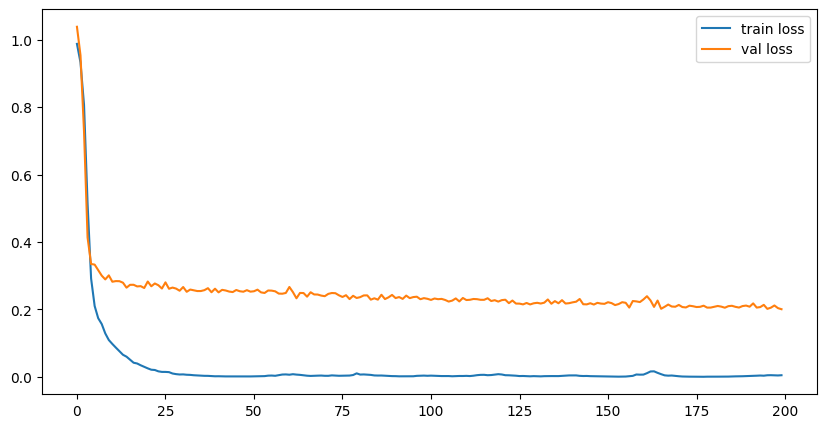

In [8]:
fig, ax = plt.subplots(figsize=(10,5))  # 그래프 캔버스와 축 생성, 크기 지정
plt.plot(range(epochs), train_loss, label = 'train loss')  # 에폭별 학습 손실 곡선 그리기
plt.plot(range(epochs), val_loss, label = 'val loss')  # 에폭별 검증 손실 곡선 그리기
plt.legend()  # 범례 표시
plt.show()  # 그래프 출력

# 규제(dropout) 정규화, early stopping

기존 AdvancedModel의 레이어 사이에 배치정규화(BatchNorm1d) 와 드랍아웃(Dropout) 을 자동으로 삽입해 새 모델(new_model) 을 구성

In [9]:
new_layers = []  # 기존 모델 레이어를 순회하며 새로운 레이어 리스트를 만들기 위한 빈 리스트
model = AdvancedModel(input_dim=20)  # AdvancedModel 인스턴스 생성 (원본 모델 구조 사용)
for i, layer in enumerate(list(model.network)):  # 모델의 Sequential 내부 레이어들을 인덱스와 함께 순회
    new_layers.append(layer)  # 원래 레이어를 먼저 추가
    if isinstance(layer, nn.Linear) and i < len( list(model.network))-1:  # 선형층이면 (출력층 제외)
        new_layers.append(nn.BatchNorm1d( layer.out_features ))  # 해당 선형층 뒤에 배치정규화 추가
    elif isinstance(layer, nn.ReLU) :  # ReLU 활성화 뒤에는
        new_layers.append(nn.Dropout(0.5))  # 드랍아웃 추가 (과적합 방지 목적)

new_model = nn.Sequential(*new_layers)  # 새로 만든 레이어 리스트로 Sequential 모델 생성
new_model

Sequential(
  (0): Linear(in_features=20, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.5, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

학습 루프는 new_model을 대상으로 최대 2000 에폭 동안 학습하고, 각 에폭마다 학습/검증 손실을 기록합니다. EarlyStopping을 사용해 검증 손실이 개선되지 않으면 학습을 조기 종료합니다.

In [10]:
from tqdm import tqdm  # 진행바 표시용
optimizer = optim.Adam(new_model.parameters(), lr=1e-2)  # 옵티마이저: Adam, 학습률 1e-2
criterion =  nn.MSELoss()  # 손실함수: 평균제곱오차 (회귀 문제에 적합)
early_stopping = EarlyStopping(patience=10)  # EarlyStopping 인스턴스 생성 (patience=10)

epochs = 2000  # 전체 학습 에폭 수 (긴 학습)
train_loss = []; val_loss = []  # 에폭별 손실 기록용 리스트 초기화
pbar = tqdm(range(epochs))  # tqdm으로 에폭 진행바 생성

best_epoch = 0  # 조기종료 발생 시의 에폭을 저장할 변수
for epoch in pbar:
    new_model.train()  # 학습 모드 설정: 드랍아웃과 배치정규화가 학습 모드로 동작
    batch_train_losses = 0.0 ; batch_val_losses=0.0  # 에폭 내 누적 손실 초기화

    for batch_x, batch_y in train_loader:  # 학습 데이터의 모든 미니배치 반복
        optimizer.zero_grad()  # 기울기 초기화
        output = new_model(batch_x)  # 모델 순전파: 예측값 계산
        loss = criterion(output, batch_y)  # 손실 계산
        loss.backward()  # 역전파: 기울기 계산
        optimizer.step()  # 가중치 갱신
        batch_train_losses += loss.item()  # 배치 손실 누적

    new_model.eval()  # 평가 모드 설정: 드랍아웃 비활성화, 배치정규화는 평가 모드로 동작
    with torch.no_grad():  # 검증 단계: 기울기 계산 비활성화(메모리 절약)
        for batch_val_x, batch_val_y in val_loader:  # 검증 데이터의 모든 미니배치 반복
            output = new_model(batch_val_x)  # 순전파
            loss = criterion(output, batch_val_y)  # 검증 손실 계산
            batch_val_losses += loss.item()  # 검증 손실 누적

    train_loss.append( batch_train_losses / len(train_loader) )  # 에폭 평균 학습 손실 저장
    val_loss.append(batch_val_losses / len(val_loader))  # 에폭 평균 검증 손실 저장
    pbar.set_postfix({'Train' : f'{train_loss[-1]:.4f}',  'val' : f'{val_loss[-1]:.4f}'})  # 진행바에 손실 표시

    if (epoch+1) % 50 == 0 or epoch == 0:  # 1번째 에폭과 50의 배수 에폭마다 로그 출력
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')

    early_stopping(val_loss[-1],new_model)  # EarlyStopping 호출: 검증 손실로 내부 상태 갱신 및 모델 저장 가능
    if early_stopping.eary_stop:  # 조기종료 플래그 확인 (주의: 변수명 오타 eary_stop)
        print(f'early stopping {train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f}')  # 조기종료 시 로그 출력 (문구에 오타 있음)
        best_epoch = epoch  # 조기종료 발생한 에폭 저장
        break  # 학습 루프 종료

  0%|          | 4/2000 [00:00<02:01, 16.45it/s, Train=0.8063, val=0.5736]

epoch 1 / 2000 train loss : 1.1099  val loss : 1.0718


  3%|▎         | 52/2000 [00:03<02:27, 13.24it/s, Train=0.4098, val=0.2244]

epoch 50 / 2000 train loss : 0.4049  val loss : 0.2457


  4%|▍         | 80/2000 [00:05<02:18, 13.85it/s, Train=0.3545, val=0.1419]

ealy stopping 0.3545 val loss : 0.1419


초기 그래프는 원래(드랍아웃/배치정규화 없는) 모델의 학습/검증 손실 추이를 보여줍니다.

두 번째 학습(배치정규화+드랍아웃 적용) 은 일반적으로 학습 안정성 향상과 과적합 완화로 이어질 수 있으며, 검증 손실이 더 안정적으로 감소하거나 더 낮은 최종 검증 손실을 얻을 가능성이 있습니다.

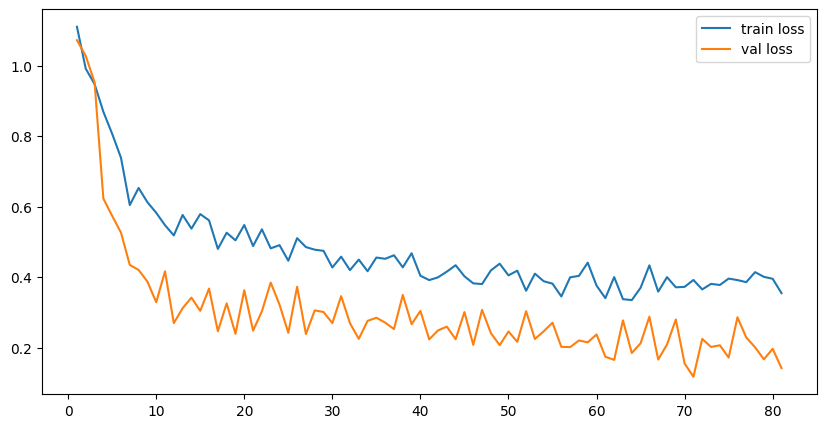

In [11]:
fig, ax = plt.subplots(figsize=(10,5))  # 조기종료 시점까지의 손실 곡선 시각화 캔버스 생성
plt.plot(range(1,best_epoch+2), train_loss, label = 'train loss')  # 1부터 best_epoch+1 까지의 학습 손실
plt.plot(range(1,best_epoch+2), val_loss, label = 'val loss')  # 1부터 best_epoch+1 까지의 검증 손실
plt.legend()  # 범례 표시
plt.show()  # 그래프 출력

# [4교시 ~ 5교시]

## [Early Stopping]

20차원 입력과 비선형 관계를 가진 합성 회귀 데이터셋을 생성

In [12]:
import torch  # PyTorch 핵심 라이브러리: 텐서 연산 및 자동미분 제공
import torch.nn as nn  # 신경망 모듈 네임스페이스 (레이어, 손실 등)
import torch.optim as optim  # 옵티마이저(Adam, SGD 등)
from torch.utils.data import TensorDataset, DataLoader, random_split  # 데이터셋 래핑, 배치 로더, 무작위 분할
import matplotlib.pyplot as plt  # 시각화용 (학습/검증 손실 플롯)
import numpy as np  # NumPy (현재 코드에서는 직접 사용되지 않음, 호환성 목적)

def create_complex_dataset(n_samples = 1200):  # 합성 데이터셋 생성 함수 (기본 샘플 수 1200)
    X = torch.randn(n_samples,20)  # (1200,20) 표준정규분포로 20차원 입력 생성
    # 비선형 및 노이즈 추가: 첫 번째 특성의 사인, 두 번째 특성의 제곱, 세 번째 특성의 절대값 반영, 작은 가우시안 노이즈 추가
    y = (torch.sin(X[:, 0] * 2) + X[:, 1]**2 - torch.abs(X[:, 2]) + torch.randn(n_samples) * 0.1).reshape(-1, 1)
    # 정규화: 평균 0, 표준편차 1로 스케일링하여 학습 안정화에 도움
    y = (y - y.mean()) / y.std()
    return TensorDataset(X,y)  # TensorDataset으로 (X, y) 쌍 반환

dataset = create_complex_dataset()  # 데이터셋 생성 호출 (기본 n_samples=1200)
train_size = int(0.8*len(dataset))  # 전체의 80%를 학습 데이터로 사용
val_size = len(dataset) - train_size  # 나머지 20%를 검증 데이터로 사용
train_dataset, val_dataset =  random_split(dataset, [train_size, val_size])  # 무작위 분할 (재현성 위해 시드 설정 권장)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # 학습용 DataLoader: 배치 32, 셔플 활성화
val_loader = DataLoader(val_dataset, batch_size=32)  

학습/검증으로 분할한 뒤 배치 로더를 준비

In [13]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path = 'best_model.pt'):
        self.patience = patience  # 개선이 없을 때 허용할 에폭 수
        self.min_delta = min_delta  # 개선으로 간주할 최소 손실 감소량
        self.path = path  # 최적 모델 저장 경로
        self.best_loss = float('inf')  # 초기 최적 손실을 무한대로 설정 (첫 측정값은 개선으로 간주)
        self.eary_stop = False  # 조기종료 플래그 (주의: 변수명 오타 eary_stop -> 일반적으로 early_stop)
        self.counter = 0  # 개선이 없었던 연속 에폭 수 카운터
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:  # 손실이 충분히 개선되었는지 확인
            self.best_loss  = val_loss  # 최적 손실 갱신
            self.counter = 0  # 카운터 리셋
            torch.save(model.state_dict(), self.path)  # 최적 모델의 state_dict 저장
        else:
            self.counter += 1  # 개선이 없으면 카운터 증가
            if self.counter >= self.patience:
                self.eary_stop = True  # 카운터가 patience 이상이면 조기종료 플래그 설정

earlystopping = EarlyStopping(patience=10)  # EarlyStopping 인스턴스 생성 (patience=10)

AdvancedModel은 선형층 + 배치정규화 + ReLU + 드랍아웃 구조의 완전연결 신경망으로 회귀 문제를 풀도록 설계되어 있습니다.

In [14]:
class AdvancedModel(nn.Module):
    def __init__(self):
      super().__init__()  # nn.Module 초기화
      self.network = nn.Sequential(
        nn.Linear(20,128),  # 입력 20 -> 128 유닛 선형층
        nn.BatchNorm1d(128),  # 배치 정규화: 학습 안정화 및 수렴 가속
        nn.ReLU(),  # 활성화 함수
        nn.Dropout(0.3),  # 드랍아웃: 과적합 방지

        nn.Linear(128,64),  # 128 -> 64 선형층
        nn.BatchNorm1d(64),  # 배치 정규화
        nn.ReLU(),  # 활성화
        nn.Dropout(0.3),  # 드랍아웃

        nn.Linear(64,32),  # 64 -> 32 선형층
        nn.BatchNorm1d(32),  # 배치 정규화
        nn.ReLU(),  # 활성화
        nn.Dropout(0.5),  # 드랍아웃 (더 강한 드랍아웃)

        nn.Linear(32,1)  # 출력층: 회귀용 단일 값 출력
        )
    def forward(self, x):
        return self.network(x)  # 순전파: 입력을 순차 네트워크에 통과시켜 출력 반환

model = AdvancedModel()  # 모델 인스턴스 생성

학습 루프는 Adam 옵티마이저와 MSE 손실을 사용해 최대 500 에폭 동안 학습하며, ReduceLROnPlateau로 검증 손실이 개선되지 않으면 학습률을 줄이고, EarlyStopping으로 개선이 없을 때 학습을 조기 종료합니다.

In [15]:
from tqdm import tqdm  # 진행바 표시용 유틸리티
epochs = 500  # 전체 학습 에폭 수
lr = 0.0001  # 학습률 설정
optimizer = optim.Adam(model.parameters() ,lr=lr)  # Adam 옵티마이저
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=5)  # 검증 손실이 개선되지 않으면 학습률 감소
criterion = nn.MSELoss()  # 회귀용 평균제곱오차 손실 함수

train_losses = []; val_losses = []  # 에폭별 손실 기록용 리스트 초기화

pbar = tqdm(range(epochs))  # tqdm으로 에폭 진행바 생성
for epoch in pbar:
    model.train()  # 학습 모드 설정: 드랍아웃 활성화, 배치정규화는 학습 모드로 동작
    t_loss= 0  # 에폭 내 학습 손실 누적 변수 초기화
    for x, y in train_loader:  # 학습 데이터의 모든 미니배치 반복
        optimizer.zero_grad()  # 기울기 초기화
        output = model(x)  # 모델 순전파: 예측값 계산
        loss = criterion(output, y)  # 손실 계산 (MSE)
        loss.backward()  # 역전파: 기울기 계산
        optimizer.step()  # 옵티마이저 스텝: 가중치 갱신
        t_loss +=loss.item()  # 배치 손실 누적

    v_loss = 0  # 검증 손실 누적 변수 초기화
    model.eval()  # 평가 모드 설정: 드랍아웃 비활성화, 배치정규화는 평가 모드로 동작
    with torch.no_grad():  # 검증 단계: 기울기 계산 비활성화(메모리 절약)
        for vx, vy in val_loader:  # 검증 데이터의 모든 미니배치 반복
            v_loss += criterion(model(vx),vy).item()  # 검증 손실 누적

    avg_train = t_loss / len(train_loader)  # 에폭 평균 학습 손실 계산
    avg_val = v_loss / len(val_loader)  # 에폭 평균 검증 손실 계산
    train_losses.append(avg_train); val_losses.append(avg_val)  # 손실 기록

    pbar.set_postfix({'t-loss': f'{avg_train:.4f}' , 'val-loss' : f'{avg_val:.4f}'  })  # 진행바에 손실 표시

    scheduler.step(avg_val)  # 스케줄러에 검증 손실 전달하여 필요시 학습률 감소
    earlystopping(avg_val,model)  # EarlyStopping 호출: 검증 손실로 내부 상태 갱신 및 모델 저장 가능
    if earlystopping.eary_stop:  # 조기종료 플래그 확인 (주의: 변수명 오타 eary_stop)
        break  # 조기종료 발생 시 학습 루프 탈출

 28%|██▊       | 138/500 [00:08<00:22, 16.12it/s, t-loss=0.5821, val-loss=0.3641]


실행하면 train_losses와 val_losses에 에폭별 손실이 쌓이고, 마지막에 두 손실 곡선이 플롯됩니다. 이상적으로는 학습 손실과 검증 손실이 모두 감소하고 검증 손실이 안정화되면 모델이 잘 학습된 것으로 볼 수 있습니다.

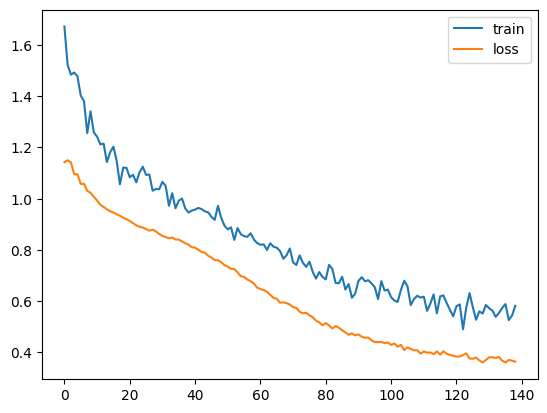

In [16]:
plt.plot(range(len(train_losses)),train_losses,label='train'   )  # 학습 손실 곡선 그리기
plt.plot(range(len(train_losses)),val_losses,label='loss'   )  # 검증 손실 곡선 그리기 (레이블 'loss'는 'val'로 바꿔도 좋음)
plt.legend()  # 범례 표시